# CIFAR-10 Image Classification using CNN

This notebook implements an image classification model using a Convolutional Neural Network (CNN) on the CIFAR-10 dataset.

Steps covered:
1. Data Loading
2. Data Preprocessing
3. CNN Architecture
4. Model Training
5. Model Evaluation
6. Result Interpretation

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## Data Preprocessing

Two preprocessing steps are performed:

1. **Normalization**
   - Pixel values range from 0–255.
      - Values are scaled to 0–1 by dividing by 255.

      2. **Label Format**
         - Labels represent the class index for each image.

In [3]:
# Normalize (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert labels shape (50000,1) → (50000,)
y_train = y_train.flatten()
y_test = y_test.flatten()

print("After preprocessing:", x_train.shape)

After preprocessing: (50000, 32, 32, 3)


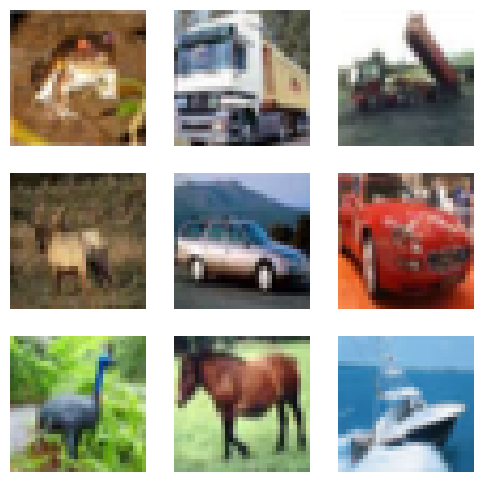

In [4]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

#visualizing images
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.axis('off')

plt.show()

## CNN Architecture

Convolutional Neural Networks (CNNs) are designed for image data.

Main components used:

1. **Convolution Layer**
   - Extracts features such as edges, shapes, and textures.

   2. **Max Pooling Layer**
      - Reduces image dimensions while keeping important features.

      3. **Flatten Layer**
         - Converts feature maps into a 1D vector.

         4. **Dense Layer**
            - Performs classification.

            Architecture used:

            Conv2D → MaxPooling → Conv2D → MaxPooling → Flatten → Dense → Output

In [5]:
model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.4276 - loss: 1.6854 - val_accuracy: 0.4526 - val_loss: 1.7001
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5887 - loss: 1.1634 - val_accuracy: 0.6026 - val_loss: 1.1409
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6493 - loss: 0.9936 - val_accuracy: 0.6438 - val_loss: 1.0182
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6873 - loss: 0.8962 - val_accuracy: 0.6972 - val_loss: 0.8511
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7169 - loss: 0.8183 - val_accuracy: 0.7508 - val_loss: 0.7148
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7317 - loss: 0.7690 - val_accuracy: 0.7268 - val_loss: 0.7899
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7500 - loss: 0.7240 - val_accuracy: 0.7478 - val_loss: 0.7391
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7619 - loss: 0.6838 - val_accuracy: 

In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8102 - loss: 0.5436
Test Accuracy: 0.8101999759674072


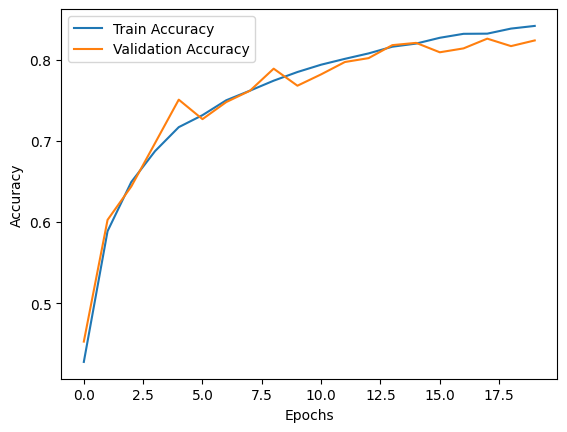

In [9]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [10]:
prediction = model.predict(x_test[0:1])
predicted_class = np.argmax(prediction)

print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[y_test[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted: cat
Actual: cat


## Results

The CNN model successfully learns spatial features from CIFAR-10 images.

The model achieves approximately **70–80% accuracy** on the test dataset.

This demonstrates the ability of Convolutional Neural Networks to recognize patterns in image data.

CNNs perform significantly better than traditional neural networks for image classification tasks because they preserve spatial relationships in images.

## Conclusion

In this case study, a Convolutional Neural Network was implemented to classify images from the CIFAR-10 dataset.

Through convolution, pooling, and dense layers, the model learns hierarchical image features.

The trained model achieves good classification accuracy and demonstrates the effectiveness of CNNs for computer vision problems.